### Non-linear data

In [9]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

In [10]:
from sklearn.datasets import make_moons

## Generating the Moon Dataset

We generate the **Moon dataset** using Scikit-learn's `make_moons()` function. This synthetic dataset contains two interleaving crescent-shaped clusters, making it ideal for comparing clustering algorithms such as **K-Means** and **DBSCAN**. Its non-linear structure helps demonstrate how different algorithms handle complex cluster shapes.

In [11]:
X, y = make_moons(
    n_samples=300,
    noise=0.05,
    random_state=42
)

## Scaling and Visualizing the Dataset

Before comparing **K-Means** and **DBSCAN**, we standardize the dataset using **StandardScaler** so that all features contribute equally during clustering. We then visualize the scaled data to better understand its distribution and the non-linear shape of the Moon dataset before applying the clustering algorithms.

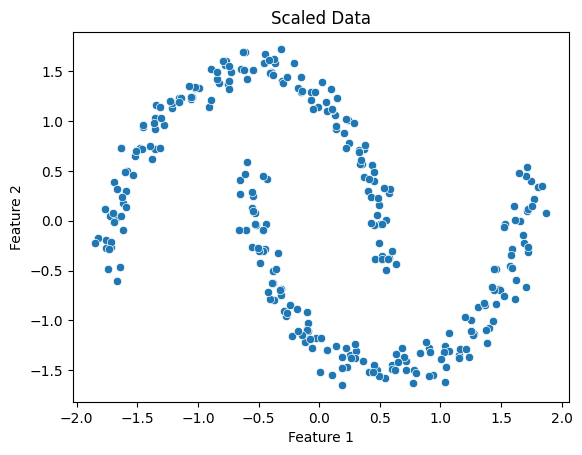

In [12]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Create scaler
scaler = StandardScaler()

# Scale features
X_scaled = scaler.fit_transform(X)

# Plot first two scaled features
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1])

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scaled Data")
plt.show()

## Applying K-Means Clustering

In this step, we apply the **K-Means** clustering algorithm to the standardized dataset. We set **`n_clusters=2`** because the Moon dataset contains two natural groups. K-Means partitions the data by assigning each point to the nearest cluster centroid and iteratively updates the centroids until the clusters stabilize.

In [13]:
# K-Means
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

labels = kmeans.fit_predict(X_scaled)

## Visualizing the K-Means Clusters

The scatter plot shows the clusters created by the **K-Means** algorithm. Each color represents a different cluster, allowing us to observe how K-Means partitions the Moon dataset based on the distance between data points and the cluster centroids.

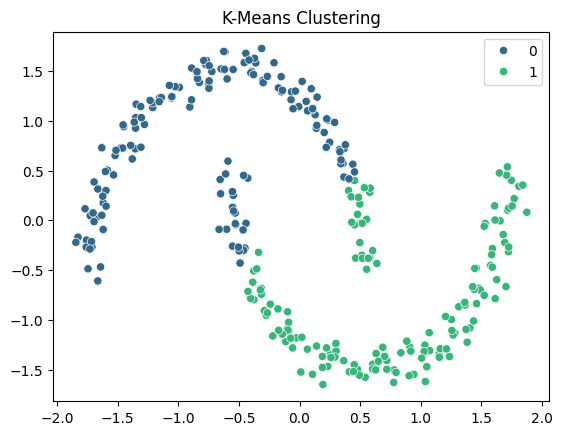

In [14]:
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels, palette="viridis")
plt.title("K-Means Clustering")
plt.show()

## Applying DBSCAN Clustering

In this step, we apply the **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** algorithm to the standardized dataset. Unlike K-Means, DBSCAN groups data points based on their **density** and does not require the number of clusters to be specified in advance. It can also identify isolated points as **noise (outliers)**, making it effective for datasets with irregular cluster shapes such as the Moon dataset.

In [15]:
# DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

labels = dbscan.fit_predict(X_scaled)

## Visualizing the DBSCAN Clusters

The scatter plot shows the clusters identified by **DBSCAN**. Unlike K-Means, DBSCAN groups points based on data density and labels isolated points as **noise** (typically shown with the label **-1**). This makes it effective for discovering clusters with irregular shapes and identifying outliers.

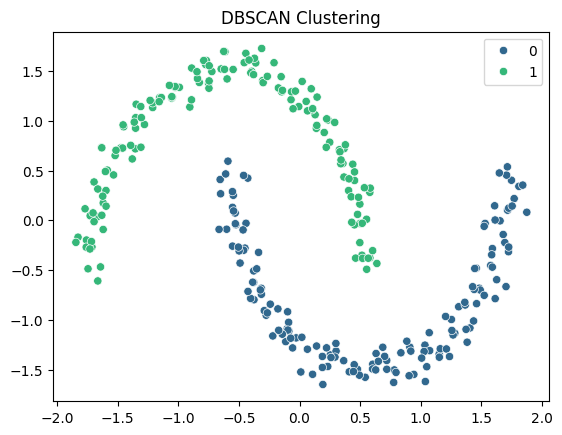

In [16]:
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels, palette="viridis")
plt.title("DBSCAN Clustering")
plt.show()

> **K-Means** performs best on spherical, well-separated clusters, whereas **DBSCAN** gives better results on non-linear datasets with irregular cluster shapes and noise.

